# 1.5 — Sigmoid & Friends, at the computer

Do the **pen-and-paper worksheet first**. Here you meet the activation functions in person,
watch a stack of linear layers collapse into a ruler, and see one kink fix everything.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt
from plots import plot_functions, axes_through_origin

sigmoid = lambda x: 1 / (1 + np.exp(-x))   # np.exp(x) computes e**x
relu    = lambda x: np.maximum(0, x)       # np.maximum: element-wise 'pick the bigger'

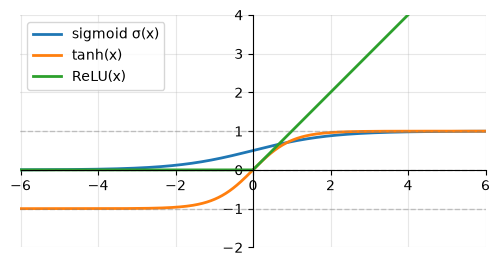

In [2]:
# The trio, in person. Check against your Part B sketches: centres, asymptotes, the kink.

ax = plot_functions({
    "sigmoid σ(x)": sigmoid,
    "tanh(x)":      np.tanh,
    "ReLU(x)":      relu,
}, xlim=(-6, 6), ylim=(-2, 4))
for level in (0, 1, -1):
    ax.axhline(level, color="gray", linestyle="--", alpha=0.4, linewidth=1)
plt.show()

# Field marks: sigmoid lives between 0 and 1, centred at (0, ½).
# tanh: same S, but between -1 and 1, centred at the origin.
# ReLU: dead flat, then a ramp — and one all-important kink at 0.

In [3]:
# Worksheet problem 12: 'my sigmoid says exactly 1.0, so 100% certain'. Let's find where
# floating point gives up on the asymptote:

for x in [5, 10, 20, 36, 37, 38]:
    print(f"sigmoid({x:>2}) = {sigmoid(x):.20f}")

# Mathematically sigmoid NEVER reaches 1 — those trailing digits just fell off the end of
# what a float can store. The certainty is the computer's, not the math's.

sigmoid( 5) = 0.99330714907571526773
sigmoid(10) = 0.99995460213129760962
sigmoid(20) = 0.99999999793884630783
sigmoid(36) = 0.99999999999999977796
sigmoid(37) = 1.00000000000000000000
sigmoid(38) = 1.00000000000000000000


## 1. The linear collapse, on screen

Worksheet problem 8: composing $2x+1$ with $3x-2$ gave a line. Here's the brutal general
version — stack **five** linear layers and plot the whole tower:

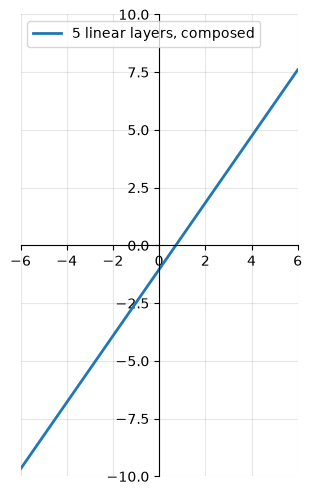

In [4]:
L1 = lambda x: 2*x + 1
L2 = lambda x: -0.5*x + 3
L3 = lambda x: 1.5*x - 2
L4 = lambda x: 0.8*x + 0.3
L5 = lambda x: -1.2*x + 1

tower = lambda x: L5(L4(L3(L2(L1(x)))))    # a five-layer 'deep network', no activations

plot_functions({"5 linear layers, composed": tower}, xlim=(-6, 6), ylim=(-10, 10))
plt.show()

# Five layers of machinery... producing one straight line. All that depth, collapsed.
# A ruler could do this. THIS is why pure linear networks are a dead end.

## 2. One kink changes everything

Same five layers — but now slip a ReLU between each pair, exactly where real networks put their
activations:

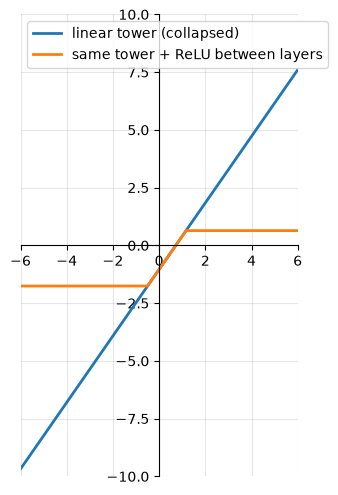

In [5]:
tower_relu = lambda x: L5(relu(L4(relu(L3(relu(L2(relu(L1(x)))))))))

plot_functions({
    "linear tower (collapsed)": tower,
    "same tower + ReLU between layers": tower_relu,
}, xlim=(-6, 6), ylim=(-10, 10))
plt.show()

# No longer a line — corners, pieces, structure. The linear layers position the kinks;
# ReLU supplies them. Depth finally BUYS something.

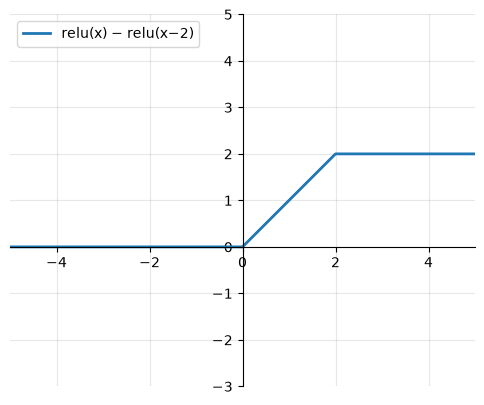

In [6]:
# YOUR TURN — two experiments from the worksheet deep-end:
#
# 1) Problem 13: what is relu(x) + relu(-x)? Add it to the plot and name the machine it builds.
# 2) Problem 14: relu(x) - relu(x - 2). Flat, ramp, flat — check your six hand-computed values.

plot_functions({
    "relu(x) − relu(x−2)": lambda x: relu(x) - relu(x - 2),
    # "relu(x) + relu(−x)": lambda x: ...,     # <- your machine for problem 13
}, xlim=(-5, 5), ylim=(-3, 5))
plt.show()

## 3. 🌀 Kinks all the way up

If a few ReLUs make corners, a *pile* of shifted, scaled ReLUs can hug any curve you like.
Below, six ReLUs impersonate a smooth wave — this is a hand-built miniature of what a trained
network does with thousands:

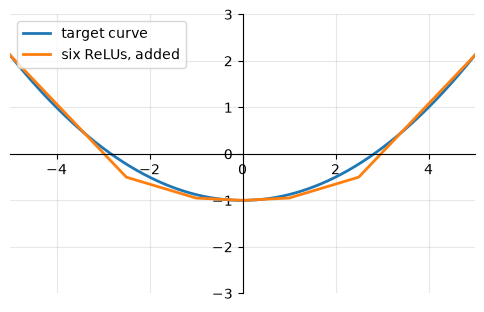

In [7]:
# target: a gentle wiggle we want to imitate
target = lambda x: x**2 / 8 - 1

# six ReLUs, each shifted (unit 1.3!) and scaled, then ADDED — weights chosen by hand:
approx = lambda x: (-1 + 0.25*relu(-x - 1) + 0.75*relu(-x - 2.5)
                       + 0.25*relu(x - 1) + 0.75*relu(x - 2.5)
                       + 0.05*relu(x) + 0.05*relu(-x))

plot_functions({
    "target curve": target,
    "six ReLUs, added": approx,
}, xlim=(-5, 5), ylim=(-3, 3))
plt.show()

# Not perfect — six kinks can only do so much. A real network uses thousands, and instead of
# me picking the weights by hand, TRAINING finds them. That sentence is deep learning.

## Module 1, assembled

You can now read the machinery of a neural network: **functions** (1.1) from the **zoo** (1.2),
**transformed** by weights and biases (1.3), **composed** into layers (1.4), with **nonlinear
activations** making depth worthwhile (1.5).

---
*Done? Photograph your worksheet into `scans/inbox/`. Then: the* ***boss worksheet***
*(`06-boss-functions`) — cold, on paper. Module 2 (Linear Algebra) and the chaos interlude*
*are on the other side.*